In [3]:
# Installing LangGraph and Gemini integration
%pip install -qU 'langgraph==0.2.45' 'langchain-google-genai==2.0.4'
# installing LangGraph (for controlling conversation flow)
# Gemini API integration (for generating chatbot responses)

# Importing necessary libraries
import os  # importing os (for setting environment variables, I need it to load your Gemini API key manually since I'm not using Kaggle)
# from kaggle_secrets import UserSecretsClient  # importing UserSecretsClient (for loading the Gemini API key securely inside Kaggle)

In [4]:
# Setting Gemini API Key manually
os.environ["GOOGLE_API_KEY"] = "xxxxxx"

In [6]:
# Defining the state of the conversation

# Importing typing tools
from typing import Annotated  # importing Annotated (for marking special fields in the state)
from typing_extensions import TypedDict  # importing TypedDict (for defining the structure of the state)

# Importing LangGraph helper
from langgraph.graph.message import add_messages  # importing add_messages (for letting LangGraph know that messages should be added, not replaced)

# Defining the order state
class OrderState(TypedDict):  # defining OrderState (for keeping track of chat, order, and finish status)

    messages: Annotated[list, add_messages]  # storing conversation messages and appending them automatically

    order: list[str]  # storing the list of ordered drinks

    finished: bool  # storing True if the user finished the order, else False

In [7]:
# Writing the system instructions (how the bot will behave)

# Defining the system instruction
BARISTABOT_SYSINT = (  # creating system instruction (for guiding the bot's behavior)
    "system",  # marking this as a system message
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user). "
    "Always confirm_order with the user (double-check) before calling place_order. "
    "Calling confirm_order will display the order items to the user and returns their response to seeing the list. "
    "Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

# Defining the welcome message
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"  # storing welcome message

In [10]:
# Creating a simple chatbot node

# Importing LangGraph core
from langgraph.graph import StateGraph, START, END  # importing graph builder and special nodes (start and end)

# Importing Gemini model
from langchain_google_genai import ChatGoogleGenerativeAI  # importing ChatGoogleGenerativeAI (for connecting to Gemini model)

# Loading Gemini model
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash-latest")  # loading Gemini model (using gemini-1.5-flash-latest for fast responses)

# Defining the chatbot node
def chatbot(state: OrderState) -> OrderState:  # creating chatbot node (for generating bot's replies)

    message_history = [BARISTABOT_SYSINT] + state["messages"]  # adding system instruction + past messages

    return {"messages": [llm.invoke(message_history)]}  # returning new message from the model

# chatbot() is a node that:
# Receives the current state.
# Sends messages + instructions to Gemini.
# Returns the AI reply.

In [11]:
# Building first minimal graph

# Building the graph
graph_builder = StateGraph(OrderState)  # creating the graph using OrderState as the state structure

# Adding the chatbot node
graph_builder.add_node("chatbot", chatbot)  # adding chatbot node (for generating AI responses)

# Connecting start → chatbot
graph_builder.add_edge(START, "chatbot")  # connecting START node to chatbot node

# Connecting chatbot → end
graph_builder.add_edge("chatbot", END)  # connecting chatbot node to END node

# Compiling the graph
chat_graph = graph_builder.compile()  # compiling the graph (making it ready to run)

In [12]:
# Running the graph for the first time (single turn)

# Importing pprint for pretty printing
from pprint import pprint  # importing pprint (for displaying full state if needed)

# Writing a user message
user_msg = ("user", "Hi, what drinks do you have?")  # creating a first user message

# Defining the initial state
state = {"messages": [user_msg]}  # setting initial state with the user's message

# Running the graph
state = chat_graph.invoke(state)  # invoking the graph (processing one step)

# Printing messages
for msg in state["messages"]:  # looping through messages (for displaying them)
    print(f"{type(msg).__name__}: {msg.content}")  # printing message type and content

HumanMessage: Hi, what drinks do you have?
AIMessage: Hi there! We have a variety of delicious drinks to choose from:

**Coffee:**

* Espresso
* Americano
* Macchiato
* Latte
* Cappuccino
* Mocha
* Flat White

**Tea:**

* Black Tea
* Green Tea
* Earl Grey

**Other:**

* Hot Chocolate
* Iced Coffee


What would you like to order?



In [13]:
# Making it handle a second turn manually

# Writing a second user message
user_msg = ("user", "I would like a latte please.")  # creating second user message

# Adding it to the state
state["messages"].append(user_msg)  # appending second user message to the conversation

# Running the graph again
state = chat_graph.invoke(state)  # invoking the graph again (processing next step)

# Printing updated conversation
for msg in state["messages"]:  # looping through messages (for displaying them)
    print(f"{type(msg).__name__}: {msg.content}")  # printing message type and content

HumanMessage: Hi, what drinks do you have?
AIMessage: Hi there! We have a variety of delicious drinks to choose from:

**Coffee:**

* Espresso
* Americano
* Macchiato
* Latte
* Cappuccino
* Mocha
* Flat White

**Tea:**

* Black Tea
* Green Tea
* Earl Grey

**Other:**

* Hot Chocolate
* Iced Coffee


What would you like to order?

HumanMessage: I would like a latte please.
AIMessage: Okay, a latte.  What size and any modifications would you like?  We have small, medium, and large.  Available modifications include:  extra shot, soy milk, almond milk, oat milk, sugar free syrup.



In [15]:
# Adding a human node to make it loop like a real conversation

# Importing AIMessage for chatbot messages
from langchain_core.messages.ai import AIMessage  # importing AIMessage (for creating messages from the bot)

# Defining the human node
def human_node(state: OrderState) -> OrderState:  # defining human node (for taking user input)
    last_msg = state["messages"][-1]  # getting the last message from the bot
    print("Model:", last_msg.content)  # printing the bot's message

    user_input = input("User: ")  # asking for user input

    if user_input.lower() in {"q", "quit", "exit", "goodbye"}:  # checking if the user wants to exit
        state["finished"] = True  # marking the state as finished

    return state | {"messages": [("user", user_input)]}  # adding the new user message to the state

# Improving the chatbot to handle welcome message
def chatbot_with_welcome_msg(state: OrderState) -> OrderState:  # defining chatbot (with welcome message)

    if state["messages"]:  # checking if there are messages already
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])  # generating normal reply
    else:
        new_output = AIMessage(content=WELCOME_MSG)  # showing welcome message if empty

    return state | {"messages": [new_output]}  # returning updated state with chatbot reply

# Building a new graph
graph_builder = StateGraph(OrderState)  # creating new graph

# Adding chatbot and human nodes
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)  # adding chatbot node
graph_builder.add_node("human", human_node)  # adding human node

# Connecting chatbot → human
graph_builder.add_edge("chatbot", "human")  # connecting chatbot to human

# Connecting human → chatbot
graph_builder.add_edge("human", "chatbot")  # connecting human back to chatbot

# Starting the graph
graph_builder.add_edge(START, "chatbot")  # connecting START to chatbot

# Compiling the graph
chat_loop_graph = graph_builder.compile()  # compiling the new looping graph

# human_node() asks for user input every time.
# chatbot_with_welcome_msg() sends a welcome message the first time.
# Now, we have a loop: chatbot → human → chatbot → human → ...

In [17]:
# Adding a clean exit condition (conditional edge)

# Defining conditional routing for the human node
from typing import Literal  # importing Literal (for limiting returned string values)

def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:  # defining router (for deciding where to go next)

    if state.get("finished", False):  # checking if finished is True
        return END  # ending the graph
    else:
        return "chatbot"  # otherwise go back to the chatbot

# Re-building the graph with the exit condition
graph_builder = StateGraph(OrderState)  # creating the graph again

graph_builder.add_node("chatbot", chatbot_with_welcome_msg)  # adding chatbot node
graph_builder.add_node("human", human_node)  # adding human node

graph_builder.add_edge(START, "chatbot")  # connecting START to chatbot

graph_builder.add_edge("chatbot", "human")  # connecting chatbot to human

graph_builder.add_conditional_edges("human", maybe_exit_human_node)  # connecting human to chatbot or END depending on finished flag

# Compiling the final version of the simple loop graph
chat_loop_with_exit_graph = graph_builder.compile()  # compiling the graph

# This is called a conditional edge.
# If the user types q, quit, exit, or goodbye → graph will go to END and stop.
# Otherwise, it will loop again to chatbot.

In [20]:
# Creating a dynamic menu tool

# Importing tool decorator
from langchain_core.tools import tool  # importing tool (for defining callable tools for the bot)

# Defining the get_menu tool
@tool  # marking function as a tool (so the bot can call it)
def get_menu() -> str:
    """Provide the latest up-to-date menu."""  # writing the required docstring

    return """
    MENU:
    Coffee Drinks:
      - Espresso
      - Americano
      - Cold Brew

    Coffee Drinks with Milk:
      - Latte
      - Cappuccino
      - Cortado
      - Macchiato
      - Mocha
      - Flat White

    Tea Drinks:
      - English Breakfast Tea
      - Green Tea
      - Earl Grey

    Tea Drinks with Milk:
      - Chai Latte
      - Matcha Latte
      - London Fog

    Other Drinks:
      - Steamer
      - Hot Chocolate

    Modifiers:
      Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free (default: Whole)
      Espresso shots: Single, Double, Triple, Quadruple (default: Double)
      Caffeine: Decaf, Regular (default: Regular)
      Hot-Iced: Hot, Iced (default: Hot)
      Sweeteners: vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
      Special requests: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.

    Soy milk is currently out of stock.
    """

# This tool provides a fixed menu, but it could later be connected to a real inventory.
# tool tells LangGraph this is a callable action the model can use.
# The model will be able to call get_menu() to fetch the up-to-date drinks list.

In [21]:
# Integrating the menu tool into the chatbot graph

# Importing ToolNode
from langgraph.prebuilt import ToolNode  # importing ToolNode (for allowing Gemini to call tools)

# Creating tool node
tools = [get_menu]  # listing available tools (here only get_menu)
tool_node = ToolNode(tools)  # creating tool node (handling automatic tool calls)

# Binding tools to the model
llm_with_tools = llm.bind_tools(tools)  # binding tools to the model (letting Gemini know it can call get_menu)

# Creating routing function
from typing import Literal  # re-importing Literal in case it's not yet imported

def maybe_route_to_tools(state: OrderState) -> Literal["tools", "human"]:  # defining routing (deciding between tools and human)
    if not (msgs := state.get("messages", [])):  # checking if messages exist
        raise ValueError("No messages found when parsing state.")  # raising error if empty

    msg = msgs[-1]  # getting last message

    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:  # checking if the bot is asking for a tool
        return "tools"  # routing to tool node
    else:
        return "human"  # routing to human node

# Updating the chatbot node to use tools
def chatbot_with_tools(state: OrderState) -> OrderState:  # defining chatbot node (now aware of tools)

    if state["messages"]:  # checking if it's mid-conversation
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])  # generating response using Gemini with tool awareness
    else:
        new_output = AIMessage(content=WELCOME_MSG)  # generating welcome message if first interaction

    return state | {"messages": [new_output]}  # updating state with the bot response


# ToolNode() allows the bot to call tools automatically.
# llm.bind_tools() tells the Gemini model which tools it is allowed to use.
# maybe_route_to_tools() lets the graph decide:
# If the bot wants to call a tool → go to tools.
# If not → go to human.

In [22]:
# Building the graph with the integrated tool

# Building the graph with the tool node
graph_builder = StateGraph(OrderState)  # creating graph with OrderState as the state

# Adding nodes
graph_builder.add_node("chatbot", chatbot_with_tools)  # adding chatbot node (now aware of tools)
graph_builder.add_node("human", human_node)  # adding human node (for receiving user input)
graph_builder.add_node("tools", tool_node)  # adding tool node (for handling get_menu calls)

# Adding edges
graph_builder.add_edge(START, "chatbot")  # connecting START to chatbot

graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)  # chatbot → tools or human depending on tool calls

graph_builder.add_edge("tools", "chatbot")  # tools always return to chatbot after execution

graph_builder.add_conditional_edges("human", maybe_exit_human_node)  # human → chatbot or END depending on user input

# Compiling the graph
graph_with_menu = graph_builder.compile()  # compiling the graph

# The graph is now tool-aware.
# Gemini can now ask for the menu dynamically by calling get_menu().

# The flow:
# Starts with the chatbot.
# If a tool is needed, it goes to the tool node.
# After tools, it returns to the chatbot.
# The human node still handles inputs and quitting.

In [23]:
# Creating order tools (add_to_order, confirm_order, get_order, clear_order, place_order)

# Importing extra modules
from collections.abc import Iterable  # importing Iterable (for listing modifiers)
from random import randint  # importing randint (for generating random preparation time)

# Importing ToolMessage for tool responses
from langgraph.prebuilt import InjectedState  # importing InjectedState (optional, used later)
from langchain_core.messages.tool import ToolMessage  # importing ToolMessage (for sending tool responses)

# Defining order tools
@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds a drink with modifiers to the order."""  # writing docstring
    pass  # placeholder (real logic will be in the next step)

@tool
def confirm_order() -> str:
    """Asks customer to confirm the order."""  # writing docstring
    pass  # placeholder

@tool
def get_order() -> str:
    """Returns the order contents so far."""  # writing docstring
    pass  # placeholder

@tool
def clear_order():
    """Clears all items from the order."""  # writing docstring
    pass  # placeholder

@tool
def place_order() -> int:
    """Places the order and returns preparation time."""  # writing docstring
    pass  # placeholder


# add_to_order(): Will be used by Gemini to add drinks.
# confirm_order(): Will ask the customer to confirm.
# get_order(): Will show the current order.
# clear_order(): Will clear the order if needed.
# place_order(): Will send the order and give an estimated time.
# (These are just declarations, we will implement their logic next.)

In [24]:
# Implementing the order logic inside order_node()

# Defining the order node logic
def order_node(state: OrderState) -> OrderState:  # defining order_node (for handling order management)

    tool_msg = state["messages"][-1]  # getting the last message which contains the tool call
    order = state.get("order", [])  # getting the current order or an empty list

    outbound_msgs = []  # preparing list to store tool responses
    order_placed = False  # tracking if the order was placed

    for tool_call in tool_msg.tool_calls:  # looping over all requested tools

        if tool_call["name"] == "add_to_order":  # handling add_to_order tool
            modifiers = tool_call["args"].get("modifiers", [])  # getting modifiers
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"  # formatting modifiers

            order.append(f'{tool_call["args"]["drink"]} ({modifier_str})')  # adding item to the order
            response = "\n".join(order)  # preparing response showing the updated order

        elif tool_call["name"] == "confirm_order":  # handling confirm_order tool
            print("Your order:")  # showing the order to the user
            if not order:
                print("  (no items)")  # showing empty order
            for drink in order:
                print(f"  {drink}")  # printing each ordered drink
            response = input("Is this correct? ")  # asking for confirmation

        elif tool_call["name"] == "get_order":  # handling get_order tool
            response = "\n".join(order) if order else "(no order)"  # showing order or "(no order)"

        elif tool_call["name"] == "clear_order":  # handling clear_order tool
            order.clear()  # clearing the order
            response = None  # no message needed

        elif tool_call["name"] == "place_order":  # handling place_order tool
            print("Sending order to kitchen!")
            print("\n".join(order))  # printing final order
            order_placed = True  # marking order as placed
            response = randint(1, 5)  # generating random preparation time

        else:
            raise NotImplementedError(f'Unknown tool call: {tool_call["name"]}')  # handling unknown tool calls

        # Recording tool results as tool messages
        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}  # returning updated state

# This is the real logic of the order system.
# It handles:
# Adding drinks.
# Confirming orders.
# Showing the current order.
# Clearing the order.
# Placing the order.

# After each tool call, the result is saved in outbound_msgs

In [26]:
# Correcting the router to include ordering node
def maybe_route_to_tools(state: OrderState) -> str:  # defining router (deciding between human, tools, or ordering)

    if not (msgs := state.get("messages", [])):  # checking if messages exist
        raise ValueError("No messages found when parsing state.")  # raising error if empty

    msg = msgs[-1]  # getting the last message

    if state.get("finished", False):  # if finished flag is True
        return END  # exiting the graph

    elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:  # if model returned tool calls

        if any(tool["name"] in [tool.name for tool in auto_tools] for tool in msg.tool_calls):  # if tool is in auto tools
            return "tools"  # routing to tool node

        else:  # otherwise it must be an order tool
            return "ordering"  # routing to ordering node

    else:
        return "human"  # otherwise, wait for human input

In [27]:
#  Connecting the order_node into the graph

# Preparing tool nodes

# Auto tools (called automatically by Gemini)
auto_tools = [get_menu]  # listing automatic tools
tool_node = ToolNode(auto_tools)  # creating tool node

# Order tools (handled manually in order_node)
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]  # listing order-related tools

# Binding all tools to the model
llm_with_tools = llm.bind_tools(auto_tools + order_tools)  # binding all tools to the model

# Building the final graph
graph_builder = StateGraph(OrderState)  # creating the graph

# Adding nodes
graph_builder.add_node("chatbot", chatbot_with_tools)  # adding chatbot node
graph_builder.add_node("human", human_node)  # adding human node
graph_builder.add_node("tools", tool_node)  # adding tool node (for auto tools)
graph_builder.add_node("ordering", order_node)  # adding ordering node (for order tools)

# Defining routing logic

# chatbot → tools / ordering / human / end
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)  # chatbot decides where to go

# human → chatbot / end
graph_builder.add_conditional_edges("human", maybe_exit_human_node)  # human can exit or continue

# tools → chatbot (always go back to chatbot after a tool)
graph_builder.add_edge("tools", "chatbot")

# ordering → chatbot (always go back to chatbot after modifying the order)
graph_builder.add_edge("ordering", "chatbot")

# start → chatbot
graph_builder.add_edge(START, "chatbot")  # connecting start to chatbot

# Compiling the graph
graph_with_order_tools = graph_builder.compile()  # compiling the final graph


# Auto tools (like get_menu) are handled automatically.
# Order tools (like add_to_order) are handled manually via order_node().

# The chatbot can:
# Route to tools if it needs the menu.
# Route to ordering if it needs to modify the order.
# Route to human if it's waiting for user input.
# Route to END if the conversation is finished.

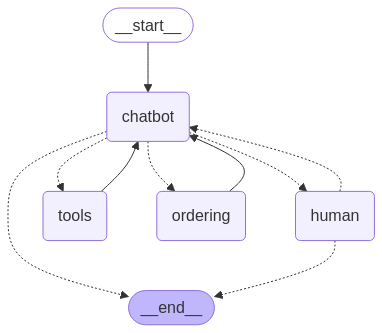

In [28]:
# To visualise the graph
# LangGraph provides a built-in way to visualize the graph using Mermaid diagrams and automatically renders them as images:

from IPython.display import Image  # importing Image (for displaying the graph as an image)

# Visualizing the graph
Image(graph_with_order_tools.get_graph().draw_mermaid_png())  # generating and displaying the graph

In [29]:
# Running the complete BaristaBot

# Running the full system

# Increasing recursion limit (optional, allows longer conversations)
config = {"recursion_limit": 100}  # setting recursion limit to 100 (for longer conversations)

# Starting the bot
state = graph_with_order_tools.invoke({"messages": []}, config)  # invoking the graph with an empty conversation

# Notes:
# - we will now see the welcome message.
# - we can ask for the menu.
# - we can place an order like "I want a latte with oat milk".
# - we can modify order.
# - Type 'q' or 'quit' anytime to end the conversation.

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: I want a latte 
Model: OK. We have a standard Latte on the menu.  Is that what you would like?



User: yes
Model: Great. Anything else for you?



User: food
Model: I'm sorry, I can only take drink orders at this time.  Is there anything else you would like to drink?



User: water
Model: Ok, I have added a water to your order.  Anything else?





User: no 
Model: Okay, here is your order:

Latte
Water

Is this correct?



User: yes
Sending order to kitchen!

